# Pipeline usage example

This notebook shows how to do basic GRB detection and parameter estimation using the pipeline.

If you have not configured your data path yet, update `config/config.yaml` before running the cells below.

In [ ]:
from datetime import datetime

import numpy as np

from grpype.data_io.data_handlers import TTEData
from grpype.pipeline import Detection
from grpype.detection.templates import GlitchTemplates, TemplateBank
from grpype.pipeline_executers import resolve_config

# Load configuration (prints data path for sanity).
config = resolve_config()
print(f"Using data path: {config.data_path}")

%matplotlib inline

## 1) Define a single set of pipeline parameters


In [2]:
date = datetime(2017, 8, 17, 12, 41)  # this is also convenient datetime.strptime('2017-08-17 12:41:00', '%Y-%m-%d %H:%M:%S.%f')

binning = 0.01


# Choose a single burst duration and its associated windowing parameters.
# If your burst duration is not in the list of burst durations with SNR calibration parameters, you can set
# calibrate=False in the match_filter function.
burst_duration = 0.40
rolling_window_sec = 60.0
rolling_gap_sec = burst_duration * 3
slice_seconds = 180.0

mf_threshold = 6.3
glitch_threshold = 6.3
min_dist_sec = 30  # Minimum distance between triggers in seconds


## 2) Load the data and the template bank

In [3]:
burstdata = TTEData(
    date,
    binning,
    burst_duration,
    timeslides=None,
    simulate=False,
    npar=1,  # Number of parallel processes to use in downloading the tte data
)

tbank = TemplateBank(binning, hasamps=False)  # If your bank does not have amplitudes (detection limits), set hasamps=False.
tbank.load_templates()

glitches = GlitchTemplates(binning, 3)
glitches.load_templates()

detection = Detection(binning, burst_duration, rolling_window_sec, rolling_gap_sec)



## 3) Run the search


In [4]:
mf, maxtimes, maxtemps, triggers_met = detection.match_filter(
    burstdata,
    tbank,
    glitches,
    slice_seconds,
    mf_threshold,
    min_dist_sec,
    glitch_threshold,
    drift_corr=True,  # If you want to use drift correction in the search.
    pe_drift_corr=True,  # If you want to use drift correction in the bank parameter estimation. Note that it will just calibrate the threshold.
    calibrate=False,
)

2017-08-17 11:58:06.193477 2017-08-17 12:01:05.933960
2017-08-17 12:01:06.323961 2017-08-17 12:04:06.064444
2017-08-17 12:04:06.454445 2017-08-17 12:07:06.194928
2017-08-17 12:07:06.584929 2017-08-17 12:10:06.325412
2017-08-17 12:10:06.715414 2017-08-17 12:13:06.465897
2017-08-17 12:13:06.855898 2017-08-17 12:16:06.596381
2017-08-17 12:16:06.986382 2017-08-17 12:19:06.726865
2017-08-17 12:19:07.116866 2017-08-17 12:22:06.857349
2017-08-17 12:22:07.247350 2017-08-17 12:25:06.987834
2017-08-17 12:25:07.377835 2017-08-17 12:28:07.128318
2017-08-17 12:28:07.518319 2017-08-17 12:31:07.258802
2017-08-17 12:31:07.648803 2017-08-17 12:34:07.389286
2017-08-17 12:34:07.779287 2017-08-17 12:37:07.519771
2017-08-17 12:37:07.909772 2017-08-17 12:40:07.650255
2017-08-17 12:40:08.040256 2017-08-17 12:43:07.790739
2017-08-17 12:54:34.192584 2017-08-17 12:59:53.793443


## 4) Plotting

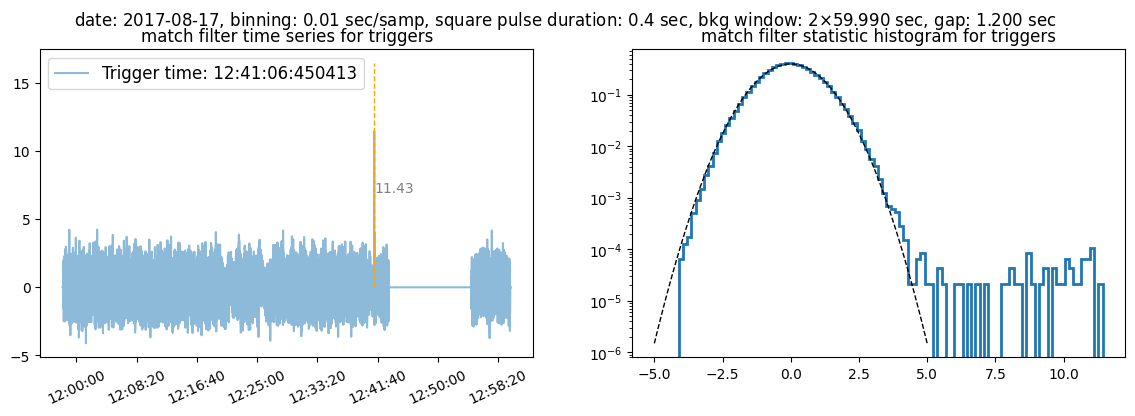

In [5]:
detection.plot_mf(
    burstdata,
    mf,
    maxtimes,
    maxtemps,
    triggers_met,
    show=True,
    return_figax=False)


For each trigger we have the match filter timeseries of the best template, with the histogram on the right. The black line is a normal distribution showed here for reference.

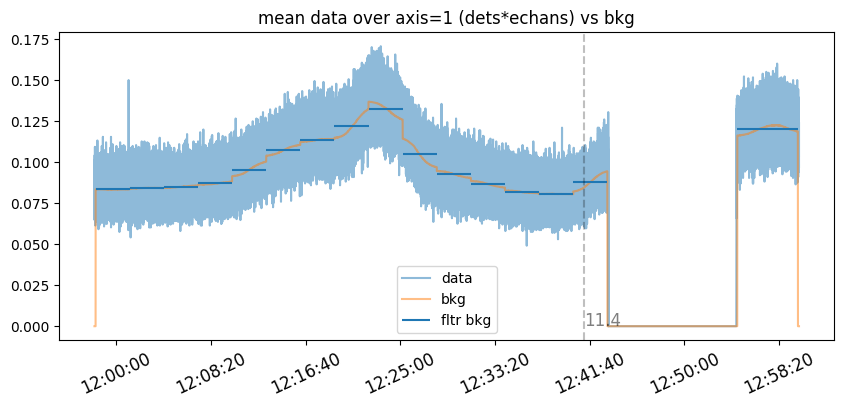

In [6]:
detection.plot_bkg(
    burstdata,
    mf,
    maxtimes,
    maxtemps,
    triggers_met,
    show=True,
    )
    

Here we plot the data summed over all detectors and over all energy channels. We also show the background estimated in the rolling window and the constant background window we use in the detection statsistic. The trigger time is marked with a vertical dashed line.

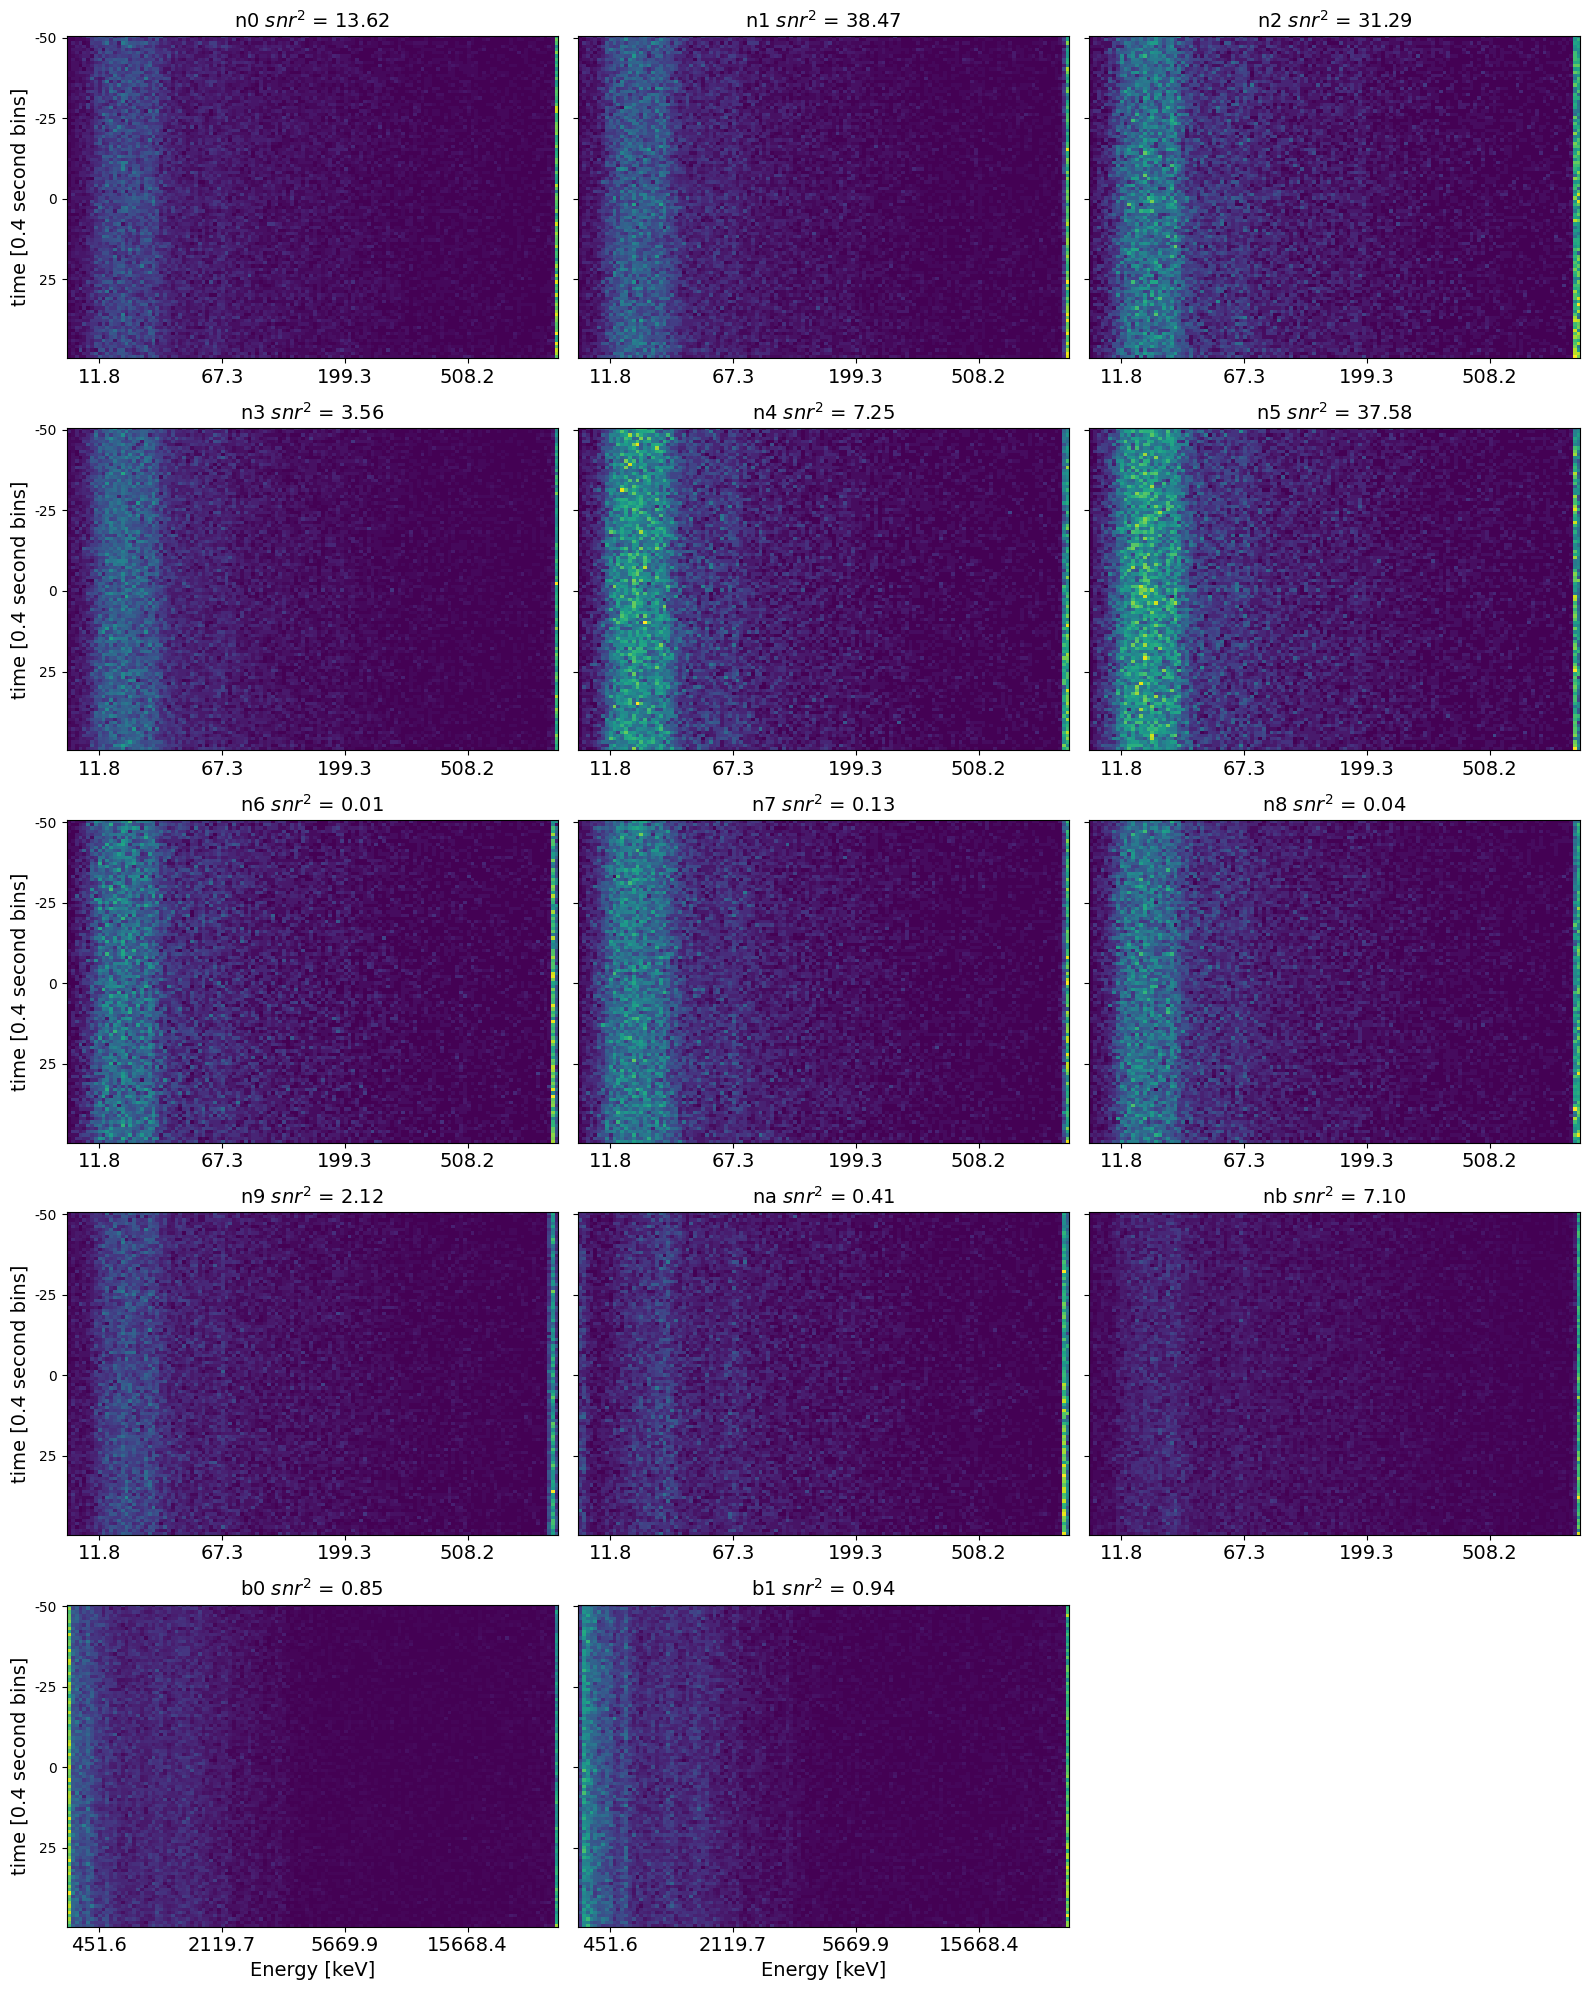

In [7]:
trignum = 0
rng = 50  # symmetric range around the trigger time in samples (i.e. sec/binning)
rebin = 40  # rebin factor for the plot

detection.plot_detectors(
    trignum,
    tbank,
    rng,
    burstdata,
    mf,
    maxtimes,
    maxtemps,
    triggers_met,
    show=True,
    return_figax=False,
    rebin=rebin,
)


The signal is faint, but with 30 ms rebinning we can see it in n5 (and maybe n1, n2 if you squint).

## 5) Paramter Estimation

Here we estimate the parameters of the burst. We need to have a full set of responses to do this. If we don't have them, we can generate by calling the response handler's class method `from_gbm_resps_bank` and specifying the angular resolution of the responses we want to use. Notice that this will take a while to run.

In [8]:
from grpype.followup.parameter_estimation import FullResponseHandler, BandFunction
from grpype.followup.parameter_estimation import extract_stats
from corner import corner
import matplotlib.pyplot as plt
from tqdm import tqdm


In [ ]:
spec_model = BandFunction()
# burstdata.set_burst_duration(0.8)  # We can change the burst duration to estimate the parameters for a different duration
offset = 0.0  # We can change the trigger time offset to estimate the parameters for a different trigger time
handler = FullResponseHandler(burstdata, triggers_met[0], burst_duration, binning, spec_model, trig_offset=offset, rsp_folder='PE_231027145949')  # PE_221220110138

# This could also be used to generate the responses for different angular resolutions. It will take a while to run.
# ang_res = 4.0
# handler = FullResponseHandler.from_gbm_resps_bank(ang_res, burstdata, trigmet, burst_duration, binning, spec_model, verbose=True, radec_bounds=bounds)

2017-08-17 12:40:08.040256 2017-08-17 12:43:07.790739


Now we construct the initial guess for the parameters from the output of the match filter.

In [10]:
trignum = 0
ra = detection.ras[trignum]
dec = detection.decs[trignum]
alpha = detection.alphas[trignum]
beta = detection.betas[trignum]
epeak = detection.epeaks[trignum]

init_guess = [ra, dec, alpha, beta, epeak]

In [11]:
sampler = handler.run_mcmc(initial_guess=init_guess, nwalkers=32, nsteps=1000)
samples = sampler.get_chain(discard=100, flat=True)

param_stats = extract_stats(samples)

display(param_stats[['ra_med', 'dec_med', 'alpha_med', 'beta_med', 'epeak_med']])
display(param_stats[['ra_max', 'dec_max', 'alpha_max', 'beta_max', 'epeak_max']])

100%|██████████| 1000/1000 [00:10<00:00, 91.82it/s]


,ra_med,dec_med,alpha_med,beta_med,epeak_med
0,188.399427,-20.220426,-0.647152,-4.753846,206.398552


,ra_max,dec_max,alpha_max,beta_max,epeak_max
0,189.66259,-20.643439,-0.637387,-4.290766,206.505071


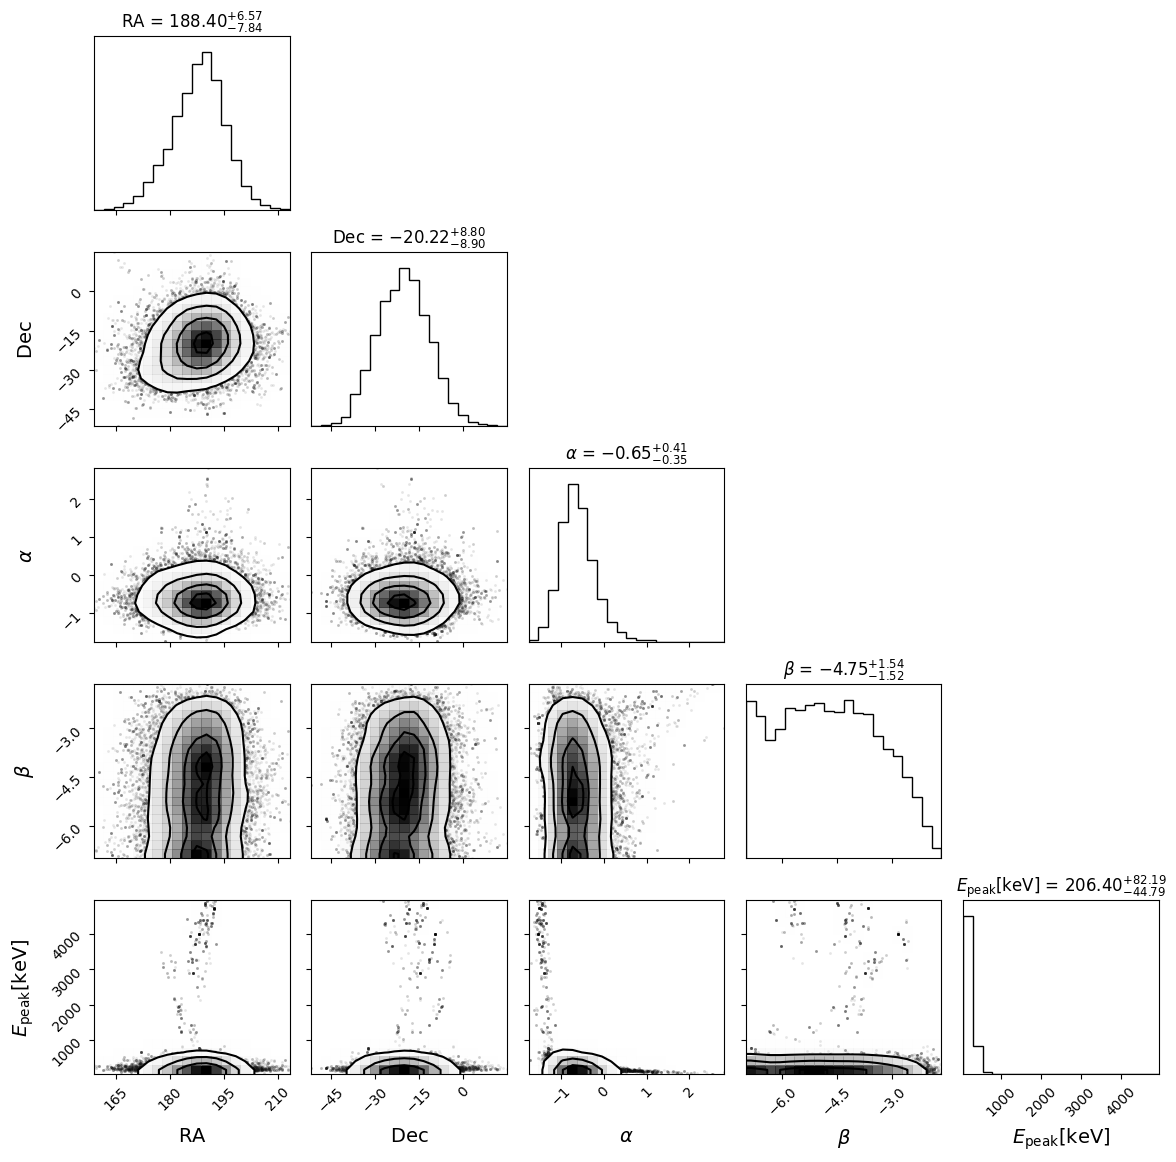

In [12]:
# ll = sampler.get_log_prob(discard=100, flat=True)
labels = [r"$\mathrm{RA}$", r"$\mathrm{Dec}$",
          r"$\alpha$", r"$\beta$", 
          r"$E_{\mathrm{peak}} [\mathrm{keV}]$", r"log-likelihood"]


fig = corner(samples, labels=labels, show_titles=True,
                    title_fmt=".2f", title_kwargs={"fontsize": 12}, 
                    label_kwargs={"fontsize": 14}, 
                    # quantiles=[0.05, 0.5, 0.95],
                    plot_density=True, plot_datapoints=True,
                    smooth=1.0)
plt.tight_layout()
plt.show()


We can also plot just the sky map of the posterior distribution marginalized over the other parameters.

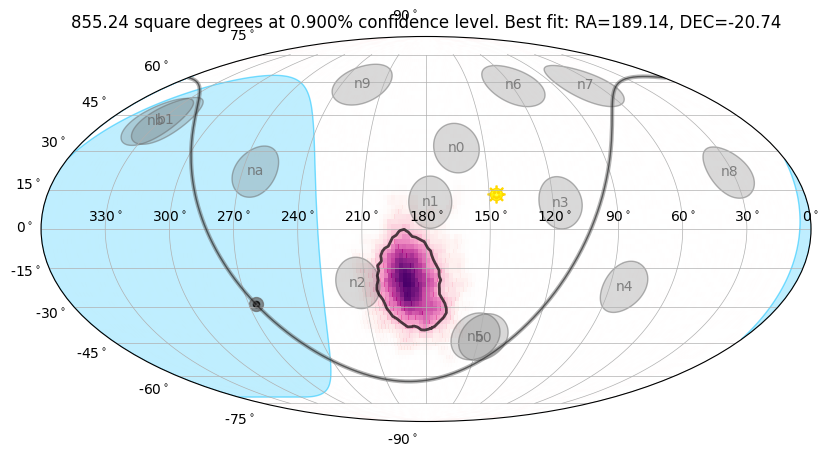

In [13]:
fermiplot, hpmap = handler.plot_skymap(samples, clevels=[0.9], fwhm_deg=3.0)

For the total energy flux, we sample the posterior distribution of the parameters and then integrate over the energy band.

2000it [00:01, 1461.55it/s]


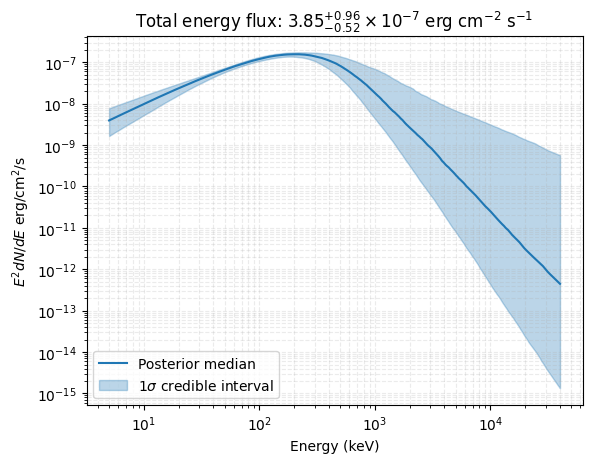

In [14]:
nsamples = 2_000
indices = np.arange(len(samples))
indices = np.random.choice(indices, nsamples, replace=True)
kev2erg = 1.60218e-9

nebins = int(1e4)
ebins = 10**np.linspace(np.log10(5), np.log10(40_000), nebins)

diff_energy_flux = np.zeros([nsamples, nebins])
tot_energy_flux = np.zeros(nsamples)

for i, ind in tqdm(enumerate(indices)):
    ra = samples[ind, 0]
    dec = samples[ind, 1]
    alpha = samples[ind, 2]
    beta = samples[ind, 3]
    epeak = samples[ind, 4]
    
    diff_photon_flux = handler.calc_diff_photon_flux(ra, dec, [alpha, beta, epeak], ebins=ebins)
    diff_energy_flux[i, :] = kev2erg*ebins**2*diff_photon_flux

    tot_energy_flux[i] = np.sum((ebins * diff_photon_flux)[:-1] * np.diff(ebins)) * kev2erg


mean_diff_energy_flux = np.median(diff_energy_flux, axis=0)
errp_diff_energy_flux = np.percentile(diff_energy_flux, 84, axis=0)
errm_diff_energy_flux = np.percentile(diff_energy_flux, 16, axis=0)

mean_tot_energy_flux = np.median(tot_energy_flux)
errp_tot_energy_flux = np.percentile(tot_energy_flux, 84) - mean_tot_energy_flux
errm_tot_energy_flux = mean_tot_energy_flux - np.percentile(tot_energy_flux, 16)

plt.plot(ebins, mean_diff_energy_flux, 'C0', label='Posterior median')
plt.fill_between(ebins, errm_diff_energy_flux, errp_diff_energy_flux, color='C0', alpha=0.3, label='1$\sigma$ credible interval')

exp = int(np.floor(np.log10(abs(mean_tot_energy_flux))))
base = mean_tot_energy_flux / (10**exp)
err_plus_base = errp_tot_energy_flux / (10**exp)
err_minus_base = errm_tot_energy_flux / (10**exp)

# Build LaTeX title string
title = ('Total energy flux: '
    fr"${base:.2f}^{{+{err_plus_base:.2f}}}_{{-{err_minus_base:.2f}}}"
    fr"\times 10^{{{exp}}}\ \mathrm{{erg\ cm^{{-2}}\ s^{{-1}}}}$"
)
plt.title(title, fontsize=12)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Energy (keV)')
plt.ylabel(f'$E^2 dN/dE$ erg/cm$^2$/s')
plt.grid(which='both', ls='--', alpha=0.25)
plt.legend()
plt.show()
